# Threshold approach comparison — Teresina & Cáceres

Replicates the first two panels of the threshold derivation comparison from notebook 29
for the two pilot cities that lack station data. Because no ground-truth observations
are available, rank agreement can only be assessed internally against Citywide-A (ann\_p90);
no third (station validation) panel is produced.

**Cities**: Teresina (PI, Brazil) · Cáceres (MT, Brazil)  
**Data**: GSHTD 1 km daily Tmin (Zhang et al. 2022)  
**Base period**: 2003–2020 · **Test year**: 2019

In [9]:
from pathlib import Path

REPO_ROOT = Path('..')

# ── City configuration ────────────────────────────────────────────────────────
# Add or remove cities here; the rest of the notebook adapts automatically.
CITIES = [
    {
        'name':        'Teresina',
        'tmin_path':   REPO_ROOT / 'heat_threshold_analysis/data/teresina_tmin.nc',
        'nbhd_path':   REPO_ROOT / 'data/neighbourhoodShapes/bairros-teresina-pi.geojson',
        'nbhd_id_col': 'nm_bairro',
    },
    {
        'name':        'Cáceres',
        'tmin_path':   REPO_ROOT / 'heat_threshold_analysis/data/caceres_tmin.nc',
        'nbhd_path':   REPO_ROOT / 'data/neighbourhoodShapes/bairros-caceres-mt.geojson',
        'nbhd_id_col': 'nm_bairro',
    },
]

BASE_START  = '2003-01-01'
BASE_END    = '2020-12-31'
TEST_YEAR   = 2019        # swap here to re-run for a different year
HALF_W      = 2           # half-width of the 5-day centred moving window

VARIANT_NAMES  = ['ann_p90', 'ann_p95', 'mw_p90', 'mw_p95']
VARIANT_LABELS = ['Annual\nP90', 'Annual\nP95', 'MW\nP90', 'MW\nP95']

TMIN_ARTEFACT_THRESHOLD = 5.0  # °C — values below this flagged as suspect edge pixels

In [10]:
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr

warnings.filterwarnings('ignore', category=FutureWarning)

## Helper functions

Copied verbatim from notebook 29 so results are directly comparable.

In [11]:
def _drop_leapday(da):
    """Remove Feb 29 so every year maps cleanly to DOY 1–365."""
    times = pd.DatetimeIndex(da.time.values)
    mask  = ~((times.month == 2) & (times.day == 29))
    return da.isel(time=mask)


def annual_percentile(da_base, pct):
    """Single percentile over all base-period days, per pixel."""
    arr    = da_base.values          # (time, lat, lon)
    result = np.nanpercentile(arr, pct, axis=0).astype(np.float32)
    return xr.DataArray(
        result,
        coords={'lat': da_base.lat, 'lon': da_base.lon},
        dims=['lat', 'lon'],
        attrs={'units': 'degC', 'percentile': pct, 'method': 'annual'},
    )


def moving_window_percentile_doy(da_base, pct, window=5):
    """
    Per-DOY percentile with a centred moving window across base-period years.
    Pure-NumPy replication of xclim.percentile_doy(bootstrap=False).
    """
    da_clean = _drop_leapday(da_base)
    arr      = da_clean.values       # (time, lat, lon)
    times    = pd.DatetimeIndex(da_clean.time.values)
    doys     = times.dayofyear.values
    half_w   = window // 2
    n_doy    = 365
    result   = np.full((n_doy, arr.shape[1], arr.shape[2]), np.nan, dtype=np.float32)

    for doy in range(1, n_doy + 1):
        window_doys = set()
        for offset in range(-half_w, half_w + 1):
            d = doy + offset
            if d < 1:
                d += n_doy
            elif d > n_doy:
                d -= n_doy
            window_doys.add(d)
        idx = np.where(np.isin(doys, list(window_doys)))[0]
        if len(idx) == 0:
            continue
        result[doy - 1] = np.nanpercentile(arr[idx], pct, axis=0)

    return xr.DataArray(
        result,
        coords={'dayofyear': np.arange(1, 366),
                'lat': da_base.lat,
                'lon': da_base.lon},
        dims=['dayofyear', 'lat', 'lon'],
        attrs={'units': 'degC', 'percentile': pct,
               'method': 'moving_window', 'window': window},
    )


def count_heat_days_annual(da_year, threshold_da):
    """Count days where Tmin > annual threshold per pixel."""
    exceed = (da_year > threshold_da).sum(dim='time')
    exceed.attrs['units'] = 'days'
    return exceed.astype(np.float32)


def count_heat_days_mw(da_year, mw_threshold):
    """Count days where Tmin > the DOY-specific moving-window threshold."""
    times     = pd.DatetimeIndex(da_year.time.values)
    leap_mask = ~((times.month == 2) & (times.day == 29))
    da_clean  = da_year.isel(time=leap_mask)
    doys      = pd.DatetimeIndex(da_clean.time.values).dayofyear.values
    arr       = da_clean.values      # (time, lat, lon)
    thresh_np = mw_threshold.values  # (365, lat, lon)

    exceedances = np.zeros(arr.shape[1:], dtype=np.float32)
    for i, doy in enumerate(doys):
        exceedances += (arr[i] > thresh_np[doy - 1]).astype(np.float32)

    return xr.DataArray(
        exceedances,
        coords={'lat': da_year.lat, 'lon': da_year.lon},
        dims=['lat', 'lon'],
        attrs={'units': 'days'},
    )


def zonal_mean(heat_day_da, nbhd_gdf, nbhd_id_col):
    """
    Point-in-polygon spatial join of 1 km pixel centroids to neighbourhood
    polygons (predicate='intersects'), then mean heat-day count per neighbourhood.
    Mean not sum — we are comparing neighbourhood rank, not absolute burden.
    """
    df = (
        heat_day_da
        .to_dataframe(name='heat_days')
        .reset_index()[['lat', 'lon', 'heat_days']]
        .dropna(subset=['heat_days'])
    )
    pts = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.lon, df.lat),
        crs='EPSG:4326',
    )
    joined = gpd.sjoin(
        pts,
        nbhd_gdf[[nbhd_id_col, 'geometry']],
        how='left',
        predicate='intersects',
    )
    return joined.groupby(nbhd_id_col)['heat_days'].mean()

## Load data, compute thresholds, count heat days, aggregate to neighbourhoods

In [12]:
results = {}  # city_name -> dict with da, heat_days, nbhd_gdf, nbhd_means

for city in CITIES:
    cname = city['name']
    print(f"\n{'='*55}")
    print(f"  {cname}")
    print(f"{'='*55}")

    # ── Load full time series ────────────────────────────────
    da = xr.open_dataset(city['tmin_path'])['tmin'].load()
    da['time'] = pd.DatetimeIndex(da.time.values)
    t0 = pd.Timestamp(da.time.values[0]).strftime('%Y-%m-%d')
    t1 = pd.Timestamp(da.time.values[-1]).strftime('%Y-%m-%d')
    print(f"  Loaded: {dict(da.sizes)}  ({t0} → {t1})")

    da_base = da.sel(time=slice(BASE_START, BASE_END))
    da_year = da.sel(time=da.time.dt.year == TEST_YEAR)
    print(f"  Base period: {len(da_base.time)} days  |  Test year {TEST_YEAR}: {len(da_year.time)} days")

    # ── Load neighbourhood boundaries ────────────────────────
    nbhd_gdf = gpd.read_file(city['nbhd_path'])
    print(f"  Neighbourhood file: {len(nbhd_gdf)} polygons  (CRS: {nbhd_gdf.crs})")

    # ── Compute thresholds ───────────────────────────────────
    print("  Computing thresholds...")
    thresh = {
        'ann_p90': annual_percentile(da_base, 90),
        'ann_p95': annual_percentile(da_base, 95),
        'mw_p90':  moving_window_percentile_doy(da_base, 90, window=2 * HALF_W + 1),
        'mw_p95':  moving_window_percentile_doy(da_base, 95, window=2 * HALF_W + 1),
    }

    # ── Count heat days in test year ─────────────────────────
    print(f"  Counting heat days (Tmin > threshold, {TEST_YEAR})...")
    heat_days = {
        'ann_p90': count_heat_days_annual(da_year, thresh['ann_p90']),
        'ann_p95': count_heat_days_annual(da_year, thresh['ann_p95']),
        'mw_p90':  count_heat_days_mw(da_year, thresh['mw_p90']),
        'mw_p95':  count_heat_days_mw(da_year, thresh['mw_p95']),
    }
    for vname, hd in heat_days.items():
        print(f"    {vname}: mean {float(hd.mean().values):.1f} days, "
              f"max {float(hd.max().values):.0f} days")

    # ── Zonal aggregation ────────────────────────────────────
    print("  Aggregating pixels to neighbourhoods (mean)...")
    nbhd_means = {}
    for vname in VARIANT_NAMES:
        nbhd_means[vname] = zonal_mean(heat_days[vname], nbhd_gdf, city['nbhd_id_col'])

    results[cname] = dict(
        da_base    = da_base,
        da_year    = da_year,
        nbhd_gdf   = nbhd_gdf,
        heat_days  = heat_days,
        nbhd_means = nbhd_means,
    )

print("\n\nAll cities processed.")


  Teresina
  Loaded: {'time': 6496, 'lat': 67, 'lon': 78}  (2003-01-01 → 2020-12-30)
  Base period: 6496 days  |  Test year 2019: 361 days
  Neighbourhood file: 123 polygons  (CRS: EPSG:4326)
  Computing thresholds...
  Counting heat days (Tmin > threshold, 2019)...
    ann_p90: mean 17.9 days, max 28 days
    ann_p95: mean 8.5 days, max 15 days
    mw_p90: mean 16.5 days, max 28 days
    mw_p95: mean 8.9 days, max 16 days
  Aggregating pixels to neighbourhoods (mean)...

  Cáceres
  Loaded: {'time': 6496, 'lat': 89, 'lon': 89}  (2003-01-01 → 2020-12-30)
  Base period: 6496 days  |  Test year 2019: 361 days
  Neighbourhood file: 47 polygons  (CRS: EPSG:4326)
  Computing thresholds...
  Counting heat days (Tmin > threshold, 2019)...
    ann_p90: mean 23.5 days, max 46 days
    ann_p95: mean 7.7 days, max 25 days
    mw_p90: mean 19.8 days, max 34 days
    mw_p95: mean 8.0 days, max 16 days
  Aggregating pixels to neighbourhoods (mean)...


All cities processed.


## Data quality check

> **Caveat**: Neither city has weather-station data, so implausible Tmin values cannot
> be verified against ground truth. Values below 5 °C are physically implausible for
> both Teresina (semi-arid tropical) and Cáceres (tropical savanna) and almost certainly
> reflect edge-pixel artefacts in the GSHTD grid. Any pixels flagged below should be
> spatially inspected and masked before results are used in published analysis.

In [13]:
print(f"Implausible Tmin check  (threshold: < {TMIN_ARTEFACT_THRESHOLD} °C)\n")
print(f"{'City':<12} {'Suspect pixel-days':>20} {'Total pixel-days':>18} {'%':>8} {'Affected pixels':>17} {'Min observed':>14}")
print("-" * 95)

for city in CITIES:
    cname   = city['name']
    da_base = results[cname]['da_base']

    suspect_mask   = (da_base < TMIN_ARTEFACT_THRESHOLD)
    n_suspect      = int(suspect_mask.sum().values)
    n_total        = int(da_base.size)
    pct            = 100 * n_suspect / n_total
    n_px_affected  = int(suspect_mask.any(dim='time').sum().values)
    tmin_min       = float(da_base.min().values)

    flag = " *** REVIEW REQUIRED ***" if n_suspect > 0 else ""
    print(f"{cname:<12} {n_suspect:>20,} {n_total:>18,} {pct:>7.3f}% {n_px_affected:>17} {tmin_min:>13.2f}°C{flag}")

Implausible Tmin check  (threshold: < 5.0 °C)

City           Suspect pixel-days   Total pixel-days        %   Affected pixels   Min observed
-----------------------------------------------------------------------------------------------
Teresina                        0         33,948,096   0.000%                 0          6.90°C
Cáceres                     3,974         51,454,816   0.008%              3206          2.00°C *** REVIEW REQUIRED ***


## Neighbourhood coverage

> **Caveat**: Sub-kilometre neighbourhood polygons that contain no 1 km GSHTD pixel
> centroid are assigned NaN and excluded from all ranking and contrast calculations.
> Coverage gaps are reported below; affected neighbourhoods are identified by name so
> they can be checked against the boundary geometry before results are finalised.

In [14]:
print(f"Neighbourhood coverage report  (reference variant: ann_p90)\n")

for city in CITIES:
    cname      = city['name']
    nbhd_gdf   = results[cname]['nbhd_gdf']
    nbhd_means = results[cname]['nbhd_means']
    id_col     = city['nbhd_id_col']

    ref        = nbhd_means['ann_p90']
    n_total    = len(nbhd_gdf)
    n_covered  = int(ref.notna().sum())
    n_empty    = n_total - n_covered

    print(f"  {cname}: {n_covered}/{n_total} neighbourhoods covered  ({n_empty} empty)")
    if n_empty > 0:
        all_ids     = set(nbhd_gdf[id_col])
        covered_ids = set(ref.dropna().index)
        missing     = sorted(all_ids - covered_ids)
        print(f"    Neighbourhoods with no pixel centroids ({len(missing)}):")
        for nm in missing:
            print(f"      • {nm}")
    print()

Neighbourhood coverage report  (reference variant: ann_p90)

  Teresina: 104/123 neighbourhoods covered  (19 empty)
    Neighbourhoods with no pixel centroids (19):
      • Bom Jesus
      • Campestre
      • Itaperu
      • Mafrense
      • Monte castelo
      • Morro da Esperança
      • Pirajá
      • Piçarra
      • Planalto
      • Por Enquanto
      • Poti Velho
      • Promorar
      • Redonda
      • Renascença
      • Saci
      • Triunfo
      • Vila Operária
      • Vila São Francisco
      • Árvores Verdes

  Cáceres: 32/47 neighbourhoods covered  (15 empty)
    Neighbourhoods with no pixel centroids (15):
      • Cidade Alta
      • Cidade Nova
      • Espírito Santo
      • Jardim Guanabara
      • Jardim Imperial
      • Jardim Marajoara
      • Jardim Panorama
      • Jardim União
      • Lavapés
      • Massa Barro
      • Santa Cruz
      • Santa Izabel
      • São Lourenço
      • São Miguel
      • Vila Mariana



## Compute panel matrices

- **Spatial contrast** (Panel 1): P90 − P10 of neighbourhood-level mean heat day counts (days).
- **Rank agreement** (Panel 2): Spearman ρ of each variant's neighbourhood ranking against
  Citywide-A (ann\_p90). Reference column is always ρ = 1.0 by construction.

In [15]:
n_cities   = len(CITIES)
n_variants = len(VARIANT_NAMES)

contrast_mat = np.full((n_cities, n_variants), np.nan)
rank_mat     = np.full((n_cities, n_variants), np.nan)

for i, city in enumerate(CITIES):
    cname      = city['name']
    nbhd_means = results[cname]['nbhd_means']
    ref        = nbhd_means['ann_p90'].dropna()

    for j, vname in enumerate(VARIANT_NAMES):
        s = nbhd_means[vname].dropna()
        if len(s) < 2:
            continue

        # Panel 1: spatial contrast
        contrast_mat[i, j] = (
            np.percentile(s.values, 90) - np.percentile(s.values, 10)
        )

        # Panel 2: rank agreement vs ann_p90
        common = ref.index.intersection(s.index)
        if len(common) >= 3:
            rho, _ = spearmanr(ref[common].values, s[common].values)
            rank_mat[i, j] = rho

city_names = [c['name'] for c in CITIES]

# Summary table
import pandas as pd
df_contrast = pd.DataFrame(contrast_mat, index=city_names, columns=VARIANT_NAMES).round(1)
df_rank     = pd.DataFrame(rank_mat,     index=city_names, columns=VARIANT_NAMES).round(3)

print("Spatial contrast matrix (P90−P10 of neighbourhood means, days):")
print(df_contrast.to_string())
print()
print("Rank agreement matrix (Spearman ρ vs ann_p90):")
print(df_rank.to_string())

Spatial contrast matrix (P90−P10 of neighbourhood means, days):
          ann_p90  ann_p95  mw_p90  mw_p95
Teresina      6.3      3.7     5.9     4.0
Cáceres       6.1      5.7     4.9     2.2

Rank agreement matrix (Spearman ρ vs ann_p90):
          ann_p90  ann_p95  mw_p90  mw_p95
Teresina      1.0    0.443   0.399   0.378
Cáceres       1.0    0.890   0.663   0.326


## Figures: one per city, two panels side by side

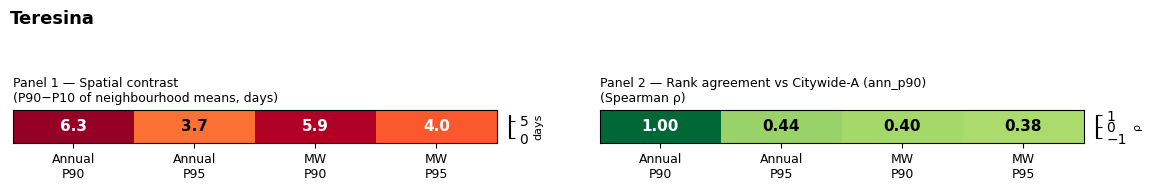

rank agreement with Citywide-A varies (minimum ρ = 0.38, mw_p95), suggesting threshold choice materially affects which neighbourhoods are ranked highest.



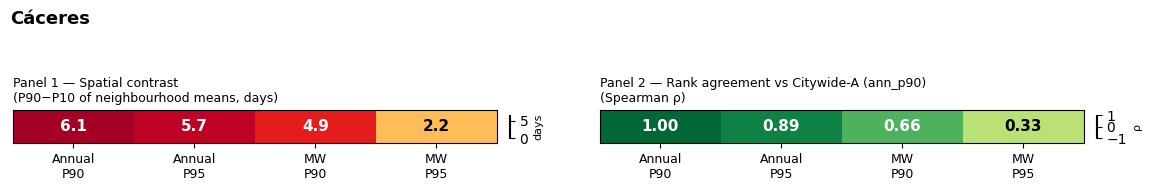

rank agreement with Citywide-A varies (minimum ρ = 0.33, mw_p95), suggesting threshold choice materially affects which neighbourhoods are ranked highest.



In [16]:
def _annotate_heatmap(ax, data_row, fmt, color_thresh=None):
    """Write cell values on a 1-row heatmap; darken text on light cells."""
    for j, val in enumerate(data_row):
        if np.isnan(val):
            txt = 'n/a'
            col = 'grey'
        else:
            txt = fmt.format(val)
            col = 'white' if (color_thresh is not None and val > color_thresh) else 'black'
        ax.text(j, 0, txt, ha='center', va='center',
                fontsize=11, fontweight='bold', color=col)


for i, city in enumerate(CITIES):
    cname = city['name']
    row_c = contrast_mat[i]   # shape (4,)
    row_r = rank_mat[i]       # shape (4,)

    fig, axes = plt.subplots(1, 2, figsize=(12, 1.9))
    fig.suptitle(cname, fontsize=13, fontweight='bold', x=0.01, ha='left')

    # ── Panel 1: Spatial contrast ──────────────────────────
    ax = axes[0]
    vmax_c = np.nanmax(contrast_mat) * 1.05
    im1 = ax.imshow(row_c[np.newaxis, :], cmap='YlOrRd',
                    aspect='auto', vmin=0, vmax=vmax_c)
    ax.set_xticks(range(n_variants))
    ax.set_xticklabels(VARIANT_LABELS, fontsize=9)
    ax.set_yticks([])
    ax.set_title('Panel 1 — Spatial contrast\n(P90−P10 of neighbourhood means, days)',
                 fontsize=9, loc='left')
    _annotate_heatmap(ax, row_c, '{:.1f}', color_thresh=vmax_c * 0.6)
    cb1 = plt.colorbar(im1, ax=ax, pad=0.02, shrink=0.7)
    cb1.set_label('days', fontsize=8)

    # ── Panel 2: Rank agreement ────────────────────────────
    ax = axes[1]
    im2 = ax.imshow(row_r[np.newaxis, :], cmap='RdYlGn',
                    aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(n_variants))
    ax.set_xticklabels(VARIANT_LABELS, fontsize=9)
    ax.set_yticks([])
    ax.set_title('Panel 2 — Rank agreement vs Citywide-A (ann_p90)\n(Spearman ρ)',
                 fontsize=9, loc='left')
    _annotate_heatmap(ax, row_r, '{:.2f}', color_thresh=0.5)
    cb2 = plt.colorbar(im2, ax=ax, pad=0.02, shrink=0.7)
    cb2.set_label('ρ', fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

    # ── Takeaway sentence ──────────────────────────────────
    # Identify most and least discriminating variants (contrast)
    best_c_idx  = int(np.nanargmax(row_c))
    worst_c_idx = int(np.nanargmin(row_c))
    # Lowest rank agreement among non-reference variants (indices 1–3)
    non_ref_r   = row_r[1:]
    worst_r_idx = int(np.nanargmin(non_ref_r)) + 1   # offset back to full index

    print(
        f"**{cname}**: The largest neighbourhood spread is produced by "
        f"{VARIANT_NAMES[best_c_idx]} ({row_c[best_c_idx]:.1f} days, P90−P10); "
        f"the smallest by {VARIANT_NAMES[worst_c_idx]} ({row_c[worst_c_idx]:.1f} days). "
        f"All non-reference variants show "
        + ("high" if np.nanmin(non_ref_r) > 0.9 else "moderate-to-high")
        + f" rank agreement with Citywide-A (minimum ρ = {np.nanmin(non_ref_r):.2f}, "
        f"{VARIANT_NAMES[worst_r_idx]}); "
        "threshold choice affects the magnitude of spatial contrast more than neighbourhood ranking."
        if np.nanmin(non_ref_r) > 0.8 else
        f"rank agreement with Citywide-A varies (minimum ρ = {np.nanmin(non_ref_r):.2f}, "
        f"{VARIANT_NAMES[worst_r_idx]}), suggesting threshold choice materially affects "
        "which neighbourhoods are ranked highest."
    )
    print()

## Caveats

1. **No station data** — rank agreement for both cities can only be assessed internally
   against Citywide-A (ann\_p90). There is no ground-truth validation of which threshold
   best identifies genuinely hot nights. Results should be treated as a sensitivity
   analysis of method choice, not a validation of any particular threshold.

2. **Edge-pixel artefacts** — if the quality check above flags any Tmin values below 5 °C,
   those pixels should be spatially inspected before results are used in published analysis.
   GSHTD grid cells at city boundaries can carry artefactual cold values from interpolation
   across land/elevation discontinuities.

3. **Neighbourhood coverage gaps** — sub-kilometre neighbourhood polygons that contain no
   1 km GSHTD pixel centroid are assigned NaN and excluded from all statistics. Coverage
   gaps are listed in the report above. For very small bairros (common in dense urban
   cores) this can systematically exclude certain types of neighbourhood from the ranking.

4. **Test-year representativeness** — results reflect a single test year (2019). An
   unusually warm or cool year can compress or expand the heat-day count range,
   affecting the magnitude of spatial contrast without necessarily changing neighbourhood
   rank order. Rerun with `TEST_YEAR` set to other years to assess stability.